In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
import joblib

warnings.filterwarnings('ignore')

# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    RandomizedSearchCV
)

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Hyperparameter distributions
from scipy.stats import randint, uniform

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

print("Libraries imported successfully")

Libraries imported successfully


Upload hotel_bookings_processed.csv


Saving hotel_bookings_processed (1).csv to hotel_bookings_processed (1).csv

Dataset : hotel_bookings_processed (1).csv
Rows    : 119,209
Columns : 21


,deposit_type_enc,country_enc,lead_time,potential_revenue,adr,market_segment_enc,adr_per_guest,total_of_special_requests,lead_time_cat_enc,room_type_changed,previous_cancellations,has_prev_cancel,required_car_parking_spaces,customer_type_enc,booking_changes,distribution_channel_enc,assigned_room_type_enc,arrival_date_year,total_nights,is_direct_booking,is_canceled
0,0,10,342,0.0,0.0,3,0.0,0,0,0,0,0,0,2,3,1,2,2015,0,1,0
1,0,10,737,0.0,0.0,3,0.0,0,0,0,0,0,0,2,4,1,2,2015,0,1,0
2,0,5,7,75.0,75.0,3,75.0,0,3,1,0,0,0,2,0,1,2,2015,1,1,0
3,0,5,13,75.0,75.0,2,75.0,0,2,0,0,0,0,2,0,0,0,2015,1,0,0
4,0,5,14,196.0,98.0,6,49.0,1,2,0,0,0,0,2,0,3,0,2015,2,0,0



Missing Values:
No missing values found

Target Distribution
Not Canceled (0) : 75,010
Canceled (1)     : 44,199


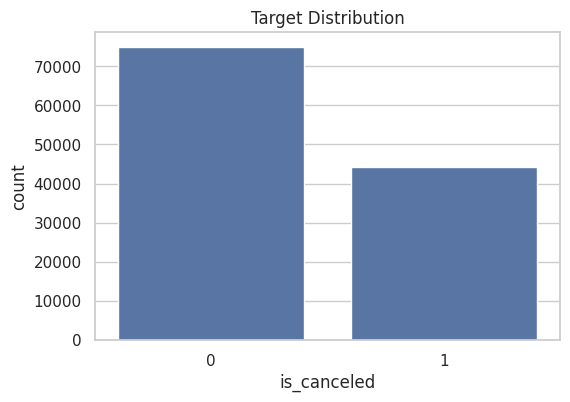

In [2]:
from google.colab import files
import io

print("Upload hotel_bookings_processed.csv")
uploaded = files.upload()
filename = list(uploaded.keys())[0]

df = pd.read_csv(io.BytesIO(uploaded[filename]))

print(f"\nDataset : {filename}")
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")

display(df.head())

# Missing Value Check
print("\nMissing Values:")

missing = df.isnull().sum()

if missing.sum() == 0:
    print("No missing values found")
else:
    display(missing[missing > 0])

# Target Distribution
print("\nTarget Distribution")

target_dist = df['is_canceled'].value_counts()

print(f"Not Canceled (0) : {target_dist[0]:,}")
print(f"Canceled (1)     : {target_dist[1]:,}")

plt.figure(figsize=(6,4))
sns.countplot(x='is_canceled', data=df)
plt.title('Target Distribution')
plt.show()

In [3]:
#DATA PREPARATION
TARGET = 'is_canceled'

X = df.drop(columns=[TARGET])
y = df[TARGET]

FEATURE_NAMES = X.columns.tolist()

print(f"Total Features : {len(FEATURE_NAMES)}")

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Train Size : {len(X_train):,}")
print(f"Test Size  : {len(X_test):,}")

# Feature Scaling, Only for Logistic Regression
scaler = StandardScaler()

X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print("Scaling completed")

Total Features : 20
Train Size : 95,367
Test Size  : 23,842
Scaling completed


In [4]:
# Verifikasi tidak ada missing value dan tipe data benar
print('Missing values per column:')
mv = df.isnull().sum()
print(mv[mv > 0] if mv.sum() > 0 else 'None — dataset is clean ')

print(f'\nTarget distribution:')
vc = df['is_canceled'].value_counts()
print(f'  Not Canceled (0): {vc[0]:,} ({vc[0]/len(df)*100:.1f}%)')
print(f'  Canceled    (1): {vc[1]:,} ({vc[1]/len(df)*100:.1f}%)')
print(f'  Class ratio : {vc[0]/vc[1]:.2f}:1 — adequately balanced for binary classification')

Missing values per column:
None — dataset is clean 

Target distribution:
  Not Canceled (0): 75,010 (62.9%)
  Canceled    (1): 44,199 (37.1%)
  Class ratio : 1.70:1 — adequately balanced for binary classification


In [5]:
# Stratified Train-Test Split (80/20)
# Stratify ensures equal class proportion in both sets — critical for imbalanced data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# StandardScaler fit ONLY on train, transform both
# Fitting on test would cause data leakage
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print('Train-Test Split (stratified):')
print(f'Train: {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'Test : {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X)*100:.1f}%)')
print(f'Cancel rate train: {y_train.mean()*100:.2f}%')
print(f'Cancel rate test : {y_test.mean()*100:.2f}%')

Train-Test Split (stratified):
Train: 95,367 samples (80.0%)
Test : 23,842 samples (20.0%)
Cancel rate train: 37.08%
Cancel rate test : 37.08%


## **SECTION 2**

In [6]:
# ─── Define 5 models ─────────────────────────────────────────────────────────
MODELS = {
    'Logistic Regression': {
        'model': LogisticRegression(max_iter=1000, random_state=42),
        'scaled': True,   # LR needs scaling
        'color': '#5C6BC0'
    },
    'Decision Tree': {
        'model': DecisionTreeClassifier(random_state=42),
        'scaled': False,
        'color': '#26A69A'
    },
    'Random Forest': {
        'model': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
        'scaled': False,
        'color': '#42A5F5'
    },
    'XGBoost': {
        'model': XGBClassifier(n_estimators=100, random_state=42, verbosity=0,
                               use_label_encoder=False, eval_metric='logloss', n_jobs=-1),
        'scaled': False,
        'color': '#EF5350'
    },
    'LightGBM': {
        'model': LGBMClassifier(n_estimators=100, random_state=42, verbosity=-1, n_jobs=-1),
        'scaled': False,
        'color': '#FFA726'
    }
}
print('5 Models defined.')

# COMPLETE RECOVERY CELL
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# CEK: kolom apa yang masih string?
str_cols = df.select_dtypes(include='object').columns.tolist()
print(f'Kolom string yang tersisa: {str_cols}')
print(f'Shape df saat ini: {df.shape}')

5 Models defined.
Kolom string yang tersisa: []
Shape df saat ini: (119209, 21)


In [7]:
# ─── Train & evaluate all 5 models ───────────────────────────────────────────
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
baseline_results = []

for name, cfg in MODELS.items():
    print(f'Training {name}...')
    t0 = time.time()
    m = cfg['model']
    Xtr = X_train_sc if cfg['scaled'] else X_train.values
    Xts = X_test_sc  if cfg['scaled'] else X_test.values

    # 5-Fold Cross-Validation on training data
    cv_acc = cross_val_score(m, Xtr, y_train, cv=cv_strategy, scoring='accuracy', n_jobs=-1)
    cv_f1  = cross_val_score(m, Xtr, y_train, cv=cv_strategy, scoring='f1',       n_jobs=-1)
    cv_auc = cross_val_score(m, Xtr, y_train, cv=cv_strategy, scoring='roc_auc',  n_jobs=-1)

    # Final fit on full training set
    m.fit(Xtr, y_train)
    yp   = m.predict(Xts)
    yprob = m.predict_proba(Xts)[:, 1] if hasattr(m, 'predict_proba') else np.zeros(len(yp))
    elapsed = time.time() - t0

    baseline_results.append({
        'Model'       : name,
        'CV_Acc'      : cv_acc.mean(),
        'CV_Acc_Std'  : cv_acc.std(),
        'CV_F1'       : cv_f1.mean(),
        'CV_AUC'      : cv_auc.mean(),
        'Test_Acc'    : accuracy_score(y_test, yp),
        'Test_Prec'   : precision_score(y_test, yp),
        'Test_Recall' : recall_score(y_test, yp),
        'Test_F1'     : f1_score(y_test, yp),
        'Test_AUC'    : roc_auc_score(y_test, yprob),
        'Time_s'      : round(elapsed, 1)
    })
    print(f' Acc={accuracy_score(y_test,yp):.4f} | F1={f1_score(y_test,yp):.4f} | AUC={roc_auc_score(y_test,yprob):.4f} | {elapsed:.1f}s\n')

df_baseline = pd.DataFrame(baseline_results).sort_values('Test_AUC', ascending=False).reset_index(drop=True)
print('\n BASELINE COMPARISON TABLE:')
df_baseline[['Model','Test_Acc','Test_Prec','Test_Recall','Test_F1','Test_AUC','Time_s']].round(4)

Training Logistic Regression...
 Acc=0.8030 | F1=0.7007 | AUC=0.8723 | 10.6s

Training Decision Tree...
 Acc=0.8475 | F1=0.7943 | AUC=0.8388 | 10.3s

Training Random Forest...
 Acc=0.8829 | F1=0.8366 | AUC=0.9504 | 127.0s

Training XGBoost...
 Acc=0.8665 | F1=0.8140 | AUC=0.9418 | 10.6s

Training LightGBM...
 Acc=0.8613 | F1=0.8055 | AUC=0.9383 | 28.9s


 BASELINE COMPARISON TABLE:


,Model,Test_Acc,Test_Prec,Test_Recall,Test_F1,Test_AUC,Time_s
0,Random Forest,0.8829,0.8665,0.8087,0.8366,0.9504,127.0
1,XGBoost,0.8665,0.8417,0.7880,0.8140,0.9418,10.6
2,LightGBM,0.8613,0.8391,0.7745,0.8055,0.9383,28.9
3,Logistic Regression,0.8030,0.8022,0.6221,0.7007,0.8723,10.6
4,Decision Tree,0.8475,0.7942,0.7945,0.7943,0.8388,10.3


TABEL LENGKAP BASELINE — 9 KOLOM (Confusion Matrix + Semua Metrik)
              Model    TN   FP   FN   TP  Accuracy  Precision  Recall     F1  ROC_AUC
Logistic Regression 13646 1356 3341 5499    0.8030     0.8022  0.6221 0.7007   0.8723
      Decision Tree 13182 1820 1817 7023    0.8475     0.7942  0.7945 0.7943   0.8388
      Random Forest 13901 1101 1691 7149    0.8829     0.8665  0.8087 0.8366   0.9504
            XGBoost 13692 1310 1874 6966    0.8665     0.8417  0.7880 0.8140   0.9418
           LightGBM 13689 1313 1993 6847    0.8613     0.8391  0.7745 0.8055   0.9383

GAMBAR BEFORE TUNING


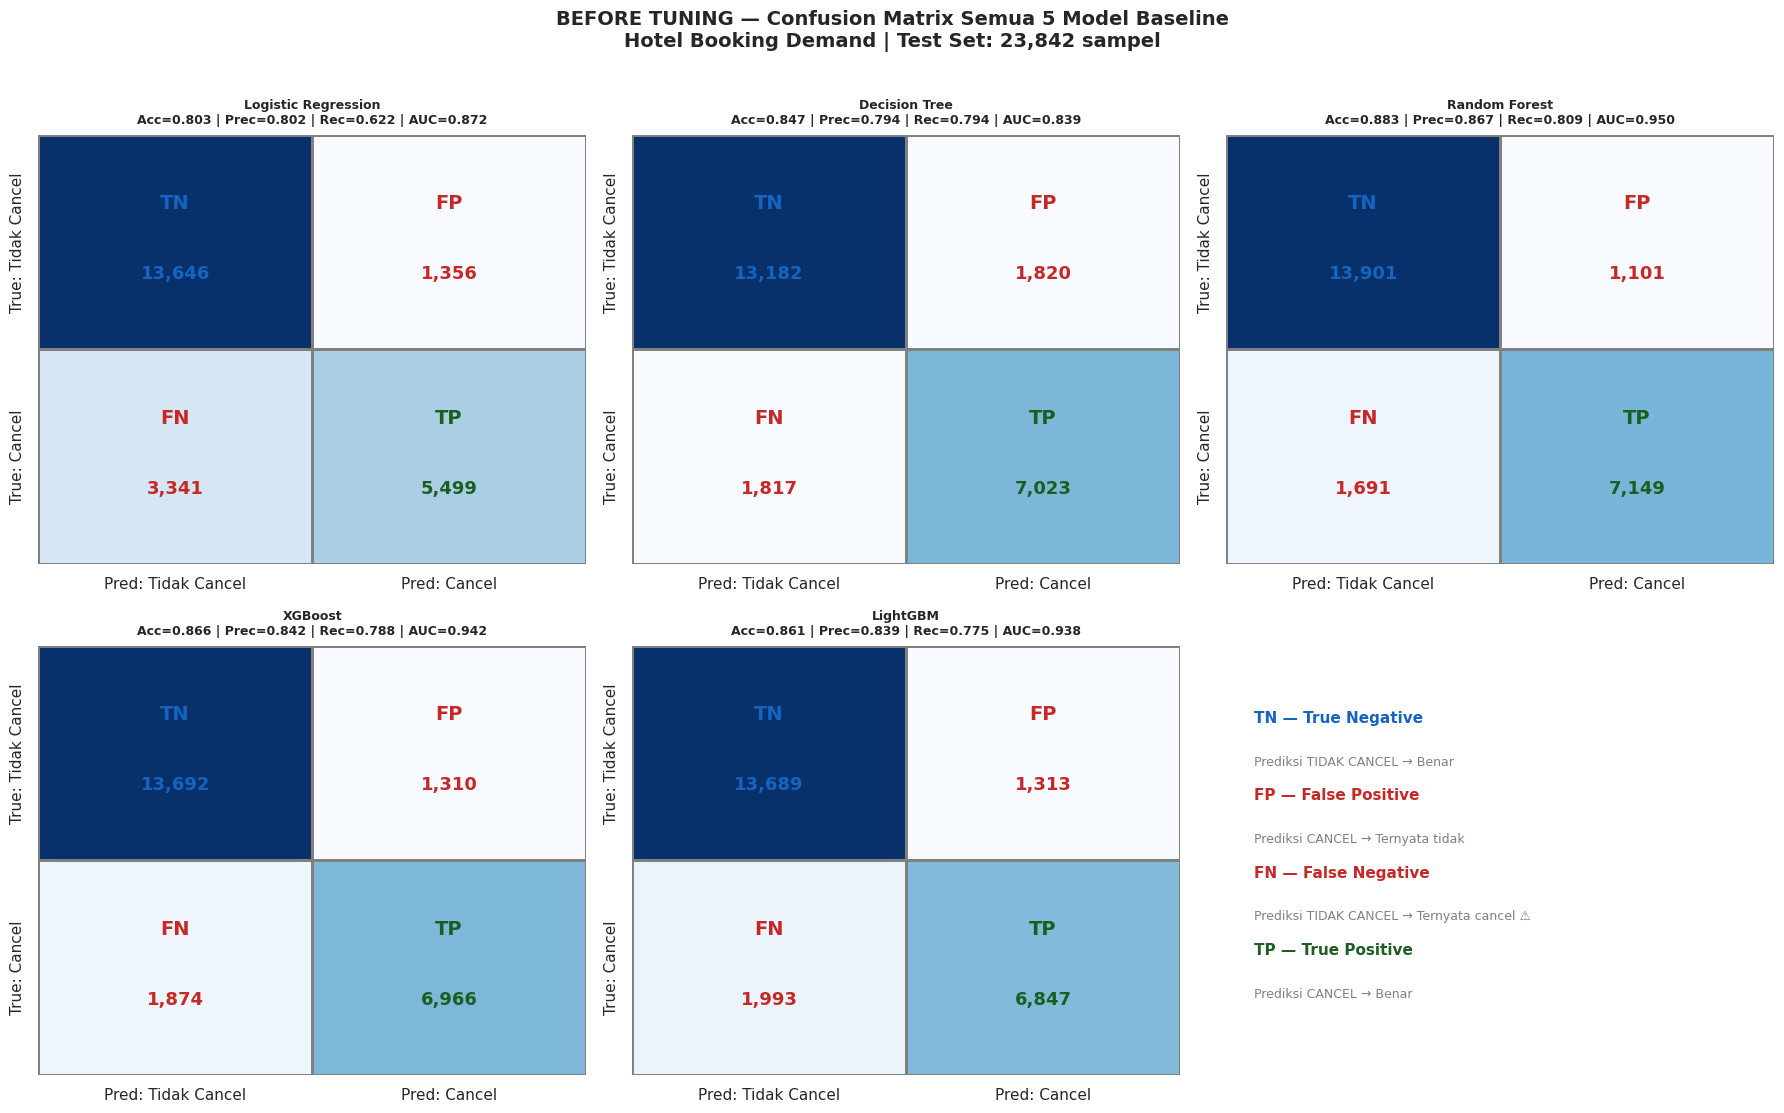

In [8]:
# GAMBAR BEFORE TUNING
print('='*90)
print('TABEL LENGKAP BASELINE — 9 KOLOM (Confusion Matrix + Semua Metrik)')
print('='*90)

full_rows = []
for name, cfg in MODELS.items():
    m    = cfg['model']
    Xts  = X_test_sc if cfg['scaled'] else X_test.values
    yp   = m.predict(Xts)
    yprob = m.predict_proba(Xts)[:, 1]
    tn, fp, fn, tp = confusion_matrix(y_test, yp).ravel()
    full_rows.append({
        'Model'    : name,
        'TN'       : tn,        # True Negative  — Benar Tidak Cancel
        'FP'       : fp,        # False Positive — Salah bilang Cancel
        'FN'       : fn,        # False Negative — Lolos tidak terdeteksi ← paling merugikan
        'TP'       : tp,        # True Positive  — Benar Cancel
        'Accuracy' : round(accuracy_score(y_test, yp), 4),
        'Precision': round(precision_score(y_test, yp), 4),
        'Recall'   : round(recall_score(y_test, yp), 4),
        'F1'       : round(f1_score(y_test, yp), 4),
        'ROC_AUC'  : round(roc_auc_score(y_test, yprob), 4),
    })

df_full_baseline = pd.DataFrame(full_rows)
print(df_full_baseline.to_string(index=False))
df_full_baseline.to_csv('baseline_full_9col.csv', index=False)
print('\n' + '='*90)
print('GAMBAR BEFORE TUNING')
print('='*90)

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes_flat = axes.flat

for (name, cfg), ax in zip(MODELS.items(), axes_flat):
    m   = cfg['model']
    Xts = X_test_sc if cfg['scaled'] else X_test.values
    yp  = m.predict(Xts)
    cm_mat = confusion_matrix(y_test, yp)
    tn, fp, fn, tp = cm_mat.ravel()

    sns.heatmap(cm_mat, annot=False, cmap='Blues', ax=ax,
                xticklabels=['Pred: Tidak Cancel', 'Pred: Cancel'],
                yticklabels=['True: Tidak Cancel', 'True: Cancel'],
                linewidths=0.8, linecolor='gray', cbar=False)

    for r, c, lbl, val, col in [
        (0, 0, 'TN', tn, '#1565C0'),
        (0, 1, 'FP', fp, '#C62828'),
        (1, 0, 'FN', fn, '#C62828'),
        (1, 1, 'TP', tp, '#1B5E20'),
    ]:
        ax.text(c+0.5, r+0.32, lbl, ha='center', va='center',
                fontsize=14, fontweight='bold', color=col)
        ax.text(c+0.5, r+0.65, f'{val:,}', ha='center', va='center',
                fontsize=13, fontweight='bold', color=col)

    auc = roc_auc_score(y_test, m.predict_proba(Xts)[:, 1])
    ax.set_title(
        f'{name}\n'
        f'Acc={accuracy_score(y_test,yp):.3f} | '
        f'Prec={precision_score(y_test,yp):.3f} | '
        f'Rec={recall_score(y_test,yp):.3f} | '
        f'AUC={auc:.3f}',
        fontweight='bold', fontsize=9, pad=8
    )

axes_flat[5].axis('off')
for i, (lbl, col, desc) in enumerate([
    ('TN — True Negative',  '#1565C0', 'Prediksi TIDAK CANCEL → Benar'),
    ('FP — False Positive', '#C62828', 'Prediksi CANCEL → Ternyata tidak'),
    ('FN — False Negative', '#C62828', 'Prediksi TIDAK CANCEL → Ternyata cancel ⚠️'),
    ('TP — True Positive',  '#1B5E20', 'Prediksi CANCEL → Benar'),
]):
    axes_flat[5].text(0.05, 0.82-i*0.18, lbl,  ha='left', fontsize=11,
                      fontweight='bold', color=col,
                      transform=axes_flat[5].transAxes)
    axes_flat[5].text(0.05, 0.72-i*0.18, desc, ha='left', fontsize=9,
                      color='gray', transform=axes_flat[5].transAxes)

plt.suptitle(
    'BEFORE TUNING — Confusion Matrix Semua 5 Model Baseline\n'
    'Hotel Booking Demand | Test Set: 23,842 sampel',
    fontweight='bold', fontsize=14, y=1.01
)
plt.tight_layout()
plt.savefig('fig_BEFORE_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

## **SECTION 3**

In [9]:
# STEP 1: Definisi param distributions
from scipy.stats import randint, uniform

rf_param_dist = {
    'n_estimators'     : randint(150, 400),
    'max_depth'        : [None, 8, 12, 16, 20],
    'min_samples_split': randint(2, 15),
    'min_samples_leaf' : randint(1, 8),
    'max_features'     : ['sqrt', 'log2', 0.5],
}

xgb_param_dist = {
    'n_estimators'    : randint(100, 400),
    'max_depth'       : randint(3, 8),
    'learning_rate'   : uniform(0.02, 0.28),
    'subsample'       : uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.5, 0.5),
    'reg_alpha'       : uniform(0, 2),
    'reg_lambda'      : uniform(0, 2),
}

lgb_param_dist = {
    'n_estimators'     : randint(100, 400),
    'max_depth'        : randint(3, 8),
    'learning_rate'    : uniform(0.02, 0.28),
    'num_leaves'       : randint(20, 80),
    'subsample'        : uniform(0.6, 0.4),
    'colsample_bytree' : uniform(0.5, 0.5),
    'reg_alpha'        : uniform(0, 2),
    'reg_lambda'       : uniform(0, 2),
}

print('Semua param distributions siap')

# Random Forest
rf_param_dist = {
    'n_estimators'     : randint(150, 400),
    'max_depth'        : [None, 8, 12, 16, 20],
    'min_samples_split': randint(2, 15),
    'min_samples_leaf' : randint(1, 8),
    'max_features'     : ['sqrt', 'log2', 0.5],
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=rf_param_dist,
    n_iter=10,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring='roc_auc', random_state=42, n_jobs=-1, verbose=1
)
print('Tuning Random Forest...')
t0 = time.time()
rf_search.fit(X_train.values, y_train)
print(f'RF done in {(time.time()-t0)/60:.1f} min')
print(f'   Best AUC    : {rf_search.best_score_:.4f}')
print(f'   Best params : {rf_search.best_params_}')

# XGBoost
xgb_param_dist = {
    'n_estimators'    : randint(100, 300),
    'max_depth'       : randint(3, 8),
    'learning_rate'   : uniform(0.02, 0.28),
    'subsample'       : uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.5, 0.5),
    'reg_alpha'       : uniform(0, 2),
    'reg_lambda'      : uniform(0, 2),
}

xgb_search = RandomizedSearchCV(
    XGBClassifier(random_state=42, verbosity=0,
                  use_label_encoder=False, eval_metric='logloss', n_jobs=-1),
    param_distributions=xgb_param_dist,
    n_iter=10,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring='roc_auc', random_state=42, n_jobs=-1, verbose=1
)
print('\nTuning XGBoost...')
t0 = time.time()
xgb_search.fit(X_train.values, y_train)
print(f'XGB done in {(time.time()-t0)/60:.1f} min')
print(f'Best AUC    : {xgb_search.best_score_:.4f}')
print(f'Best params : {xgb_search.best_params_}')

# LightGBM
lgb_param_dist = {
    'n_estimators'      : randint(100, 300),
    'max_depth'         : randint(3, 8),
    'learning_rate'     : uniform(0.02, 0.28),
    'num_leaves'        : randint(20, 80),
    'subsample'         : uniform(0.6, 0.4),
    'colsample_bytree'  : uniform(0.5, 0.5),
    'reg_alpha'         : uniform(0, 2),
    'reg_lambda'        : uniform(0, 2),
    'min_child_samples' : randint(5, 50)
}

lgb_search = RandomizedSearchCV(
    LGBMClassifier(random_state=42, verbosity=-1, n_jobs=-1),
    param_distributions=lgb_param_dist,
    n_iter=10,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring='roc_auc', random_state=42, n_jobs=-1, verbose=1
)
print('\nTuning LightGBM...')
t0 = time.time()
lgb_search.fit(X_train.values, y_train)
print(f'LGB done in {(time.time()-t0)/60:.1f} min')
print(f'Best AUC    : {lgb_search.best_score_:.4f}')
print(f'Best params : {lgb_search.best_params_}')

print('\nSemua tuning selesai!')

Semua param distributions siap
Tuning Random Forest...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
RF done in 7.8 min
   Best AUC    : 0.9426
   Best params : {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 12, 'n_estimators': 208}

Tuning XGBoost...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
XGB done in 0.5 min
Best AUC    : 0.9416
Best params : {'colsample_bytree': np.float64(0.7600340105889054), 'learning_rate': np.float64(0.1730788782161183), 'max_depth': 7, 'n_estimators': 290, 'reg_alpha': np.float64(1.684569549189997), 'reg_lambda': np.float64(0.8995082667395313), 'subsample': np.float64(0.7580600944007257)}

Tuning LightGBM...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
LGB done in 1.3 min
Best AUC    : 0.9418
Best params : {'colsample_bytree': np.float64(0.8421165132560784), 'learning_rate': np.float64(0.14324269824708838), 'max_depth': 6, 'min_child_samples': 12, 'n_estimators': 274, 'nu

## **SECTION 5**

In [10]:
# Evaluate all tuned models
tuned_models = {
    'RF (Tuned)' : {'model': rf_search.best_estimator_,  'scaled': False, 'color': '#42A5F5'},
    'XGB (Tuned)': {'model': xgb_search.best_estimator_, 'scaled': False, 'color': '#EF5350'},
    'LGB (Tuned)': {'model': lgb_search.best_estimator_, 'scaled': False, 'color': '#FFA726'}
}

tuning_results = []
for name, cfg in tuned_models.items():
    m = cfg['model']
    Xts = X_test_sc if cfg['scaled'] else X_test.values
    yp    = m.predict(Xts)
    yprob = m.predict_proba(Xts)[:, 1]
    tuning_results.append({
        'Model'    : name,
        'Accuracy' : accuracy_score(y_test, yp),
        'Precision': precision_score(y_test, yp),
        'Recall'   : recall_score(y_test, yp),
        'F1'       : f1_score(y_test, yp),
        'ROC_AUC'  : roc_auc_score(y_test, yprob)
    })

df_tuned = pd.DataFrame(tuning_results).sort_values('ROC_AUC', ascending=False).reset_index(drop=True)
print('TUNED MODEL RESULTS:')
print(df_tuned.round(4).to_string(index=False))

# Print tuning impact
print('\nTUNING IMPACT (Baseline → Tuned, ROC-AUC):')
mapping = {'RF (Tuned)':'Random Forest','XGB (Tuned)':'XGBoost','LGB (Tuned)':'LightGBM'}
for tn, bn in mapping.items():
    base_row = df_baseline[df_baseline['Model']==bn]
    tune_row = df_tuned[df_tuned['Model']==tn]
    if not base_row.empty and not tune_row.empty:
        b = base_row['Test_AUC'].values[0]
        t = tune_row['ROC_AUC'].values[0]
        print(f'  {bn:20s}: {b:.4f} → {t:.4f}  (Δ {t-b:+.4f})')

TUNED MODEL RESULTS:
      Model  Accuracy  Precision  Recall     F1  ROC_AUC
 RF (Tuned)    0.8732     0.8625  0.7829 0.8208   0.9466
XGB (Tuned)    0.8724     0.8514  0.7946 0.8220   0.9461
LGB (Tuned)    0.8685     0.8470  0.7874 0.8162   0.9439

TUNING IMPACT (Baseline → Tuned, ROC-AUC):
  Random Forest       : 0.9504 → 0.9466  (Δ -0.0039)
  XGBoost             : 0.9418 → 0.9461  (Δ +0.0042)
  LightGBM            : 0.9383 → 0.9439  (Δ +0.0056)


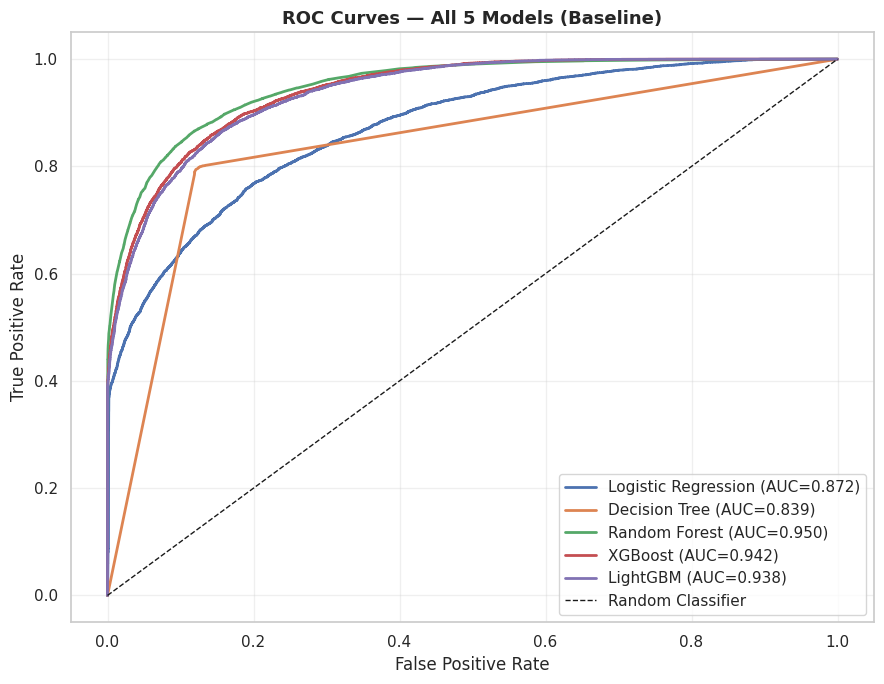

In [11]:
from sklearn.metrics import roc_curve, roc_auc_score

# ROC curves for ALL 5 baseline models
fig, ax = plt.subplots(figsize=(9,7))
for name, cfg in MODELS.items():

    m = cfg['model']
    Xts = X_test_sc if cfg['scaled'] else X_test.values

    yprob = m.predict_proba(Xts)[:,1]

    fpr, tpr, _ = roc_curve(y_test, yprob)
    auc = roc_auc_score(y_test, yprob)

    ax.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f'{name} (AUC={auc:.3f})'
    )

ax.plot([0,1],[0,1],'k--', linewidth=1,
        label='Random Classifier')
ax.set_title(
    'ROC Curves — All 5 Models (Baseline)',
    fontweight='bold',
    fontsize=13
)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(
    'fig_roc_all_models.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()

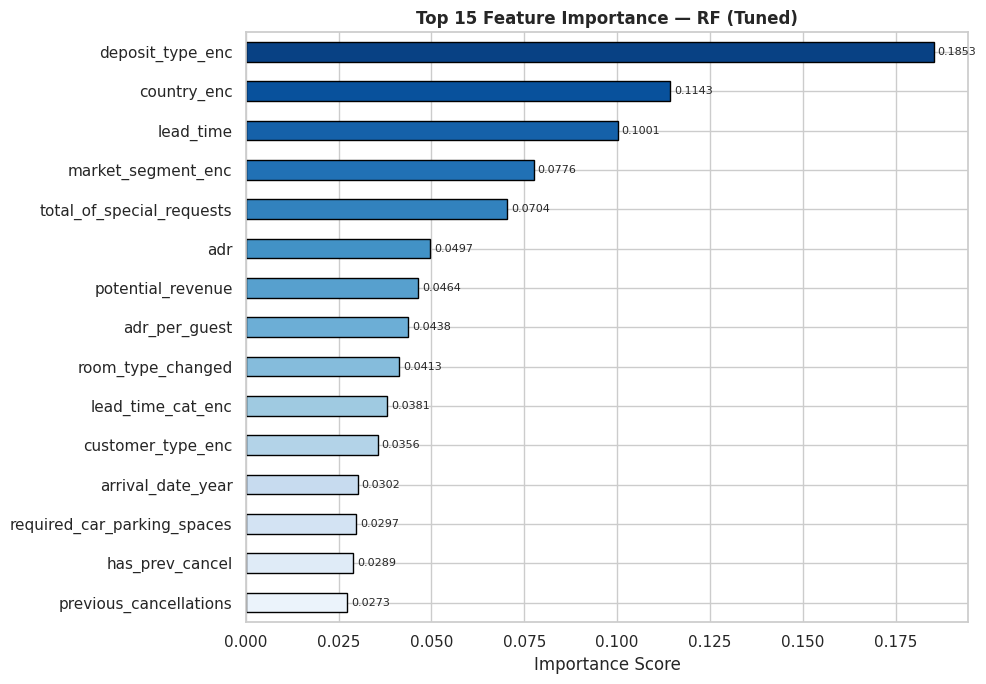


TOP 10 MOST IMPORTANT FEATURES:
 1. deposit_type_enc                    0.1853
 2. country_enc                         0.1143
 3. lead_time                           0.1001
 4. market_segment_enc                  0.0776
 5. total_of_special_requests           0.0704
 6. adr                                 0.0497
 7. potential_revenue                   0.0464
 8. adr_per_guest                       0.0438
 9. room_type_changed                   0.0413
10. lead_time_cat_enc                   0.0381


In [16]:
BEST_MODEL = rf_search.best_estimator_
BEST_NAME = 'RF (Tuned)'
if hasattr(BEST_MODEL, 'feature_importances_'):

    fi = pd.Series(
        BEST_MODEL.feature_importances_,
        index=FEATURE_NAMES
    )

    fi_top = fi.sort_values(ascending=False).head(15)

    fig, ax = plt.subplots(figsize=(10, 7))

    palette = sns.color_palette('Blues_r', len(fi_top))

    fi_top[::-1].plot(
        kind='barh',
        ax=ax,
        color=palette[::-1],
        edgecolor='black'
    )

    ax.set_title(
        f'Top 15 Feature Importance — {BEST_NAME}',
        fontweight='bold'
    )

    ax.set_xlabel('Importance Score')

    for bar in ax.patches:
        ax.text(
            bar.get_width() + 0.001,
            bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.4f}',
            va='center',
            fontsize=8
        )

    plt.tight_layout()
    plt.savefig(
        'fig_feature_importance_final.png',
        dpi=150,
        bbox_inches='tight'
    )

    plt.show()
    print('\nTOP 10 MOST IMPORTANT FEATURES:')

    for i, (feat, score) in enumerate(
        fi_top.head(10).items(), 1
    ):
        print(f'{i:2d}. {feat:<35} {score:.4f}')

else:
    print(f'{BEST_NAME} does not support feature importance.')

BEFORE vs AFTER TUNING — VISUALISASI PERBANDINGAN


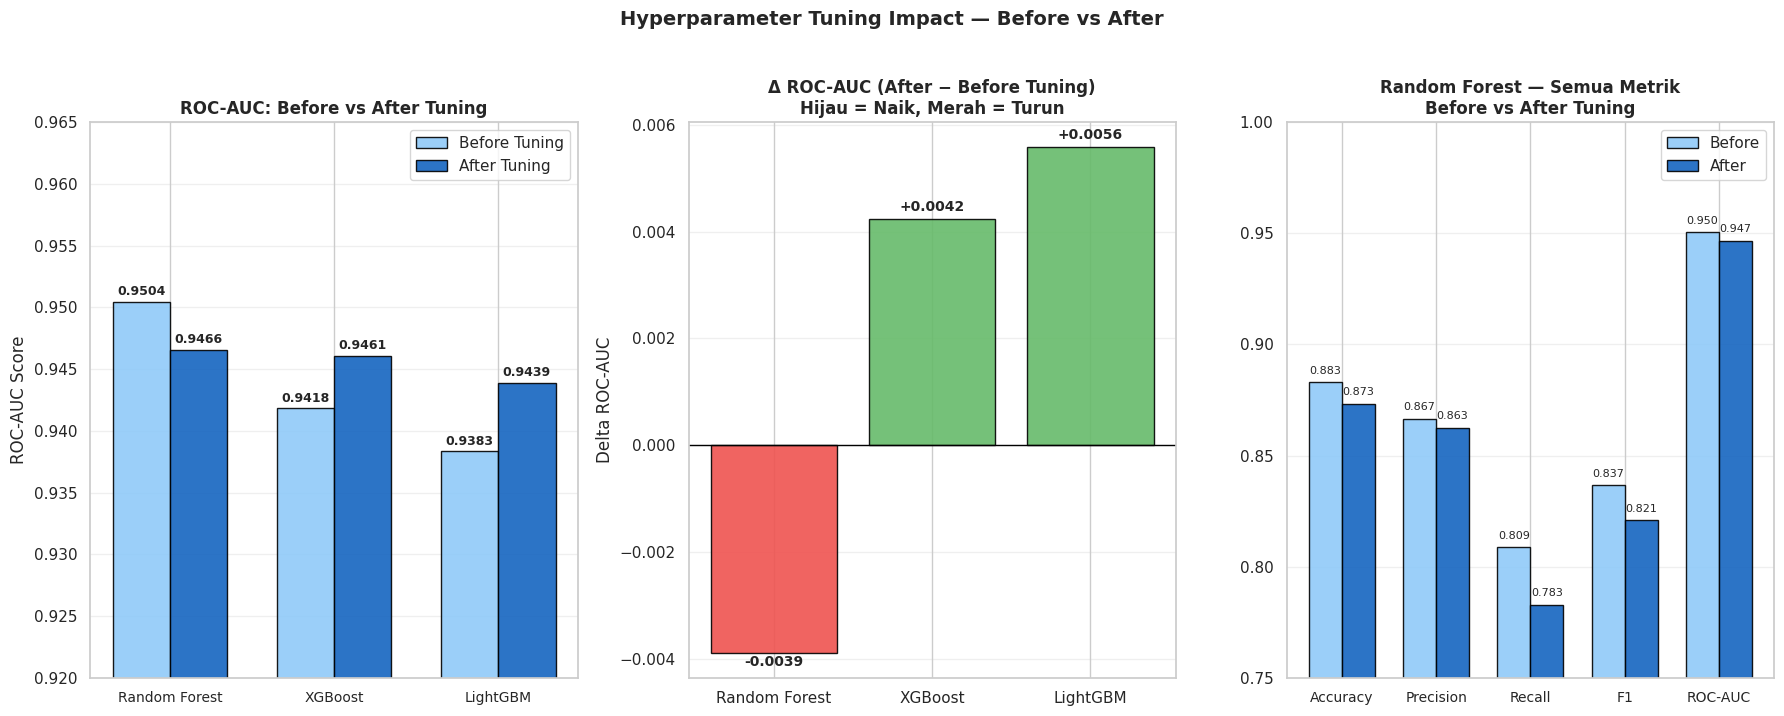

In [17]:
# Visualisasi Before vs After Tuning
print('='*65)
print('BEFORE vs AFTER TUNING — VISUALISASI PERBANDINGAN')
print('='*65)

before = {
    'Random Forest': df_baseline[df_baseline['Model']=='Random Forest']['Test_AUC'].values[0],
    'XGBoost'      : df_baseline[df_baseline['Model']=='XGBoost']['Test_AUC'].values[0],
    'LightGBM'     : df_baseline[df_baseline['Model']=='LightGBM']['Test_AUC'].values[0],
}
after = {
    'Random Forest': df_tuned[df_tuned['Model']=='RF (Tuned)']['ROC_AUC'].values[0],
    'XGBoost'      : df_tuned[df_tuned['Model']=='XGB (Tuned)']['ROC_AUC'].values[0],
    'LightGBM'     : df_tuned[df_tuned['Model']=='LGB (Tuned)']['ROC_AUC'].values[0],
}

model_names  = list(before.keys())
before_vals  = list(before.values())
after_vals   = list(after.values())

fig, axes = plt.subplots(1, 3, figsize=(18, 7))

x = np.arange(len(model_names))
w = 0.35
b1 = axes[0].bar(x - w/2, before_vals, w, label='Before Tuning',
                 color='#90CAF9', edgecolor='black', alpha=0.9)
b2 = axes[0].bar(x + w/2, after_vals,  w, label='After Tuning',
                 color='#1565C0', edgecolor='black', alpha=0.9)
axes[0].set_title('ROC-AUC: Before vs After Tuning', fontweight='bold', fontsize=12)
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names, fontsize=10)
axes[0].set_ylim(0.92, 0.965)
axes[0].set_ylabel('ROC-AUC Score')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
for bar in list(b1) + list(b2):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.0003,
                 f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

deltas = [a - b for a, b in zip(after_vals, before_vals)]
delta_colors = ['#EF5350' if d < 0 else '#66BB6A' for d in deltas]
bars_d = axes[1].bar(model_names, deltas, color=delta_colors, edgecolor='black', alpha=0.9)
axes[1].axhline(0, color='black', lw=1)
axes[1].set_title('Δ ROC-AUC (After − Before Tuning)\nHijau = Naik, Merah = Turun',
                   fontweight='bold', fontsize=12)
axes[1].set_ylabel('Delta ROC-AUC')
axes[1].grid(axis='y', alpha=0.3)
for bar, d in zip(bars_d, deltas):
    ypos = bar.get_height() + 0.0001 if d >= 0 else bar.get_height() - 0.0003
    axes[1].text(bar.get_x()+bar.get_width()/2, ypos,
                 f'{d:+.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

rf_before_metrics = {
    'Accuracy' : df_baseline[df_baseline['Model']=='Random Forest']['Test_Acc'].values[0],
    'Precision': df_baseline[df_baseline['Model']=='Random Forest']['Test_Prec'].values[0],
    'Recall'   : df_baseline[df_baseline['Model']=='Random Forest']['Test_Recall'].values[0],
    'F1'       : df_baseline[df_baseline['Model']=='Random Forest']['Test_F1'].values[0],
    'ROC-AUC'  : df_baseline[df_baseline['Model']=='Random Forest']['Test_AUC'].values[0],
}
rf_after_metrics = {
    'Accuracy' : df_tuned[df_tuned['Model']=='RF (Tuned)']['Accuracy'].values[0],
    'Precision': df_tuned[df_tuned['Model']=='RF (Tuned)']['Precision'].values[0],
    'Recall'   : df_tuned[df_tuned['Model']=='RF (Tuned)']['Recall'].values[0],
    'F1'       : df_tuned[df_tuned['Model']=='RF (Tuned)']['F1'].values[0],
    'ROC-AUC'  : df_tuned[df_tuned['Model']=='RF (Tuned)']['ROC_AUC'].values[0],
}

metrics  = list(rf_before_metrics.keys())
bef_vals = list(rf_before_metrics.values())
aft_vals = list(rf_after_metrics.values())
x2 = np.arange(len(metrics))

axes[2].bar(x2 - w/2, bef_vals, w, label='Before', color='#90CAF9', edgecolor='black', alpha=0.9)
axes[2].bar(x2 + w/2, aft_vals, w, label='After',  color='#1565C0', edgecolor='black', alpha=0.9)
axes[2].set_title('Random Forest — Semua Metrik\nBefore vs After Tuning', fontweight='bold', fontsize=12)
axes[2].set_xticks(x2)
axes[2].set_xticklabels(metrics, fontsize=10)
axes[2].set_ylim(0.75, 1.0)
axes[2].legend()
axes[2].grid(axis='y', alpha=0.3)
for bar in axes[2].patches:
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Hyperparameter Tuning Impact — Before vs After',
             fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('fig_before_after_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

CONFUSION MATRIX — SEMUA 5 MODEL BASELINE


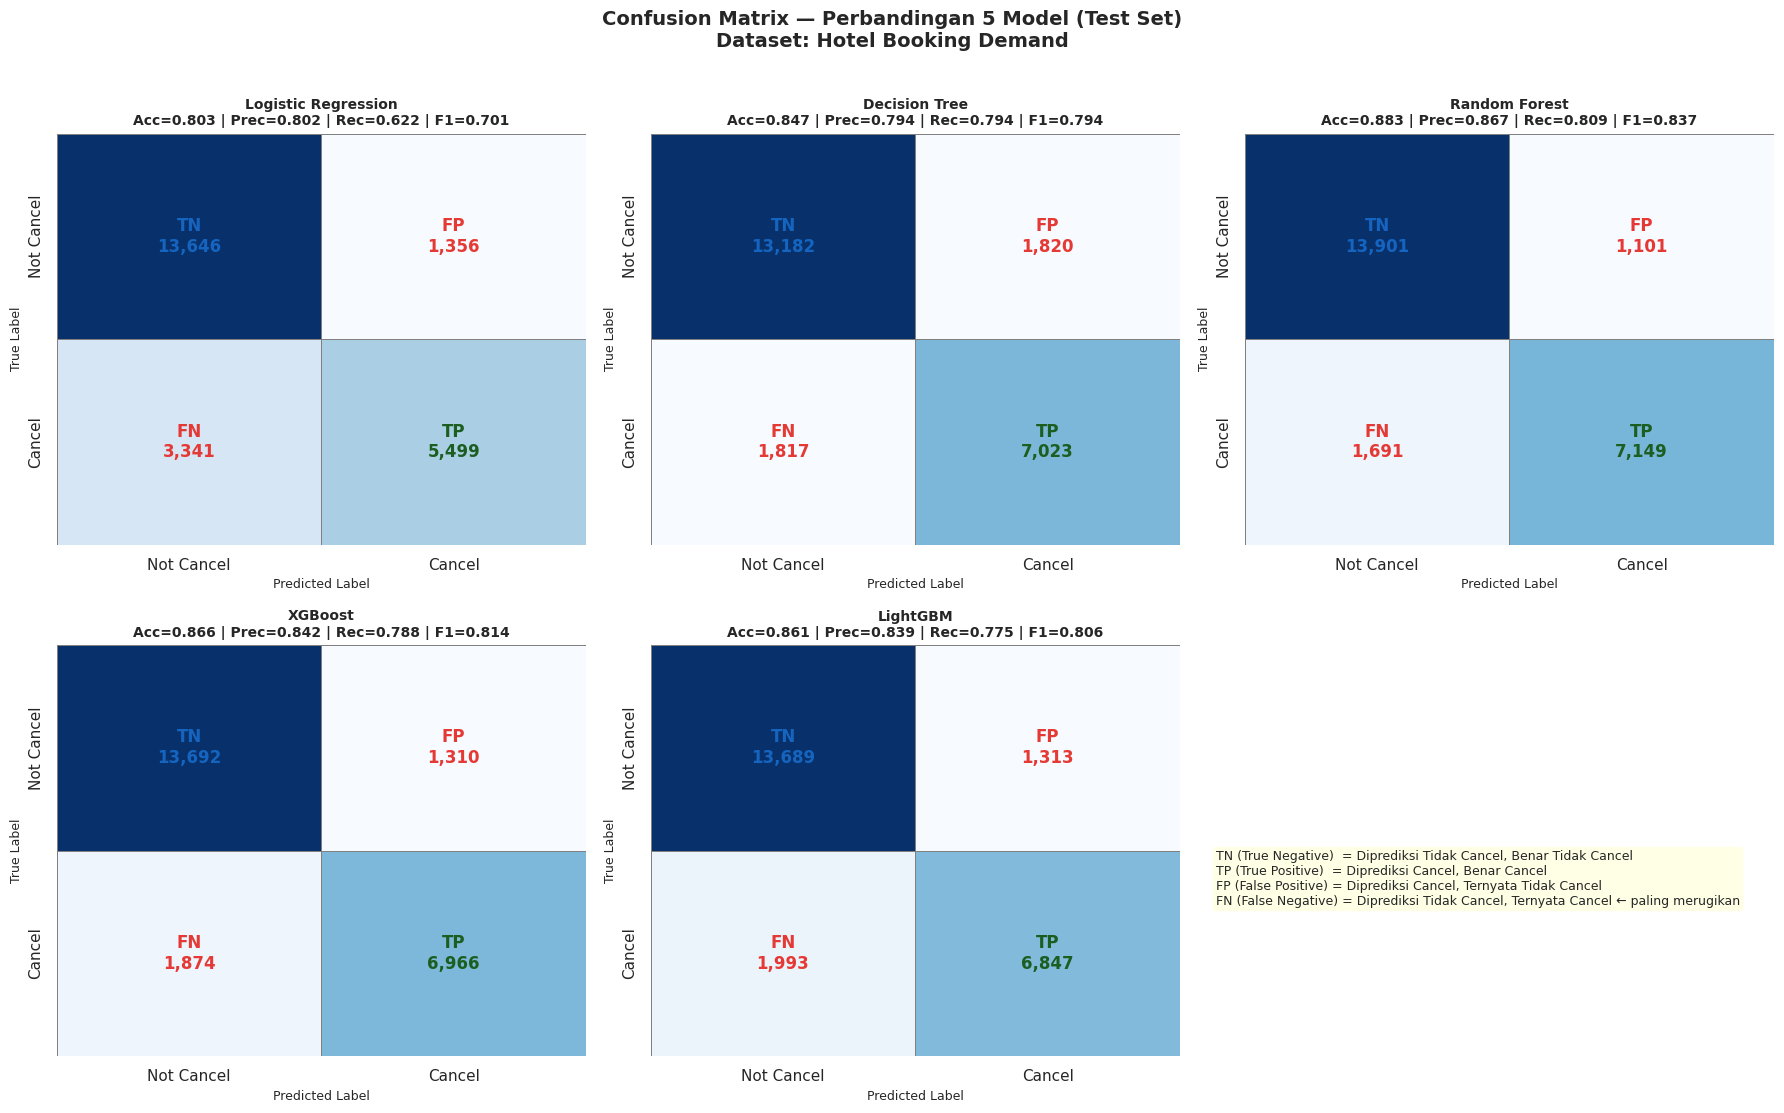

              Model  TN (Benar Tidak Cancel)  FP (Salah Cancel)  FN (Salah Tidak Cancel)  TP (Benar Cancel)  Total Benar  Total Salah
Logistic Regression                    13646               1356                     3341               5499        19145         4697
      Decision Tree                    13182               1820                     1817               7023        20205         3637
      Random Forest                    13901               1101                     1691               7149        21050         2792
            XGBoost                    13692               1310                     1874               6966        20658         3184
           LightGBM                    13689               1313                     1993               6847        20536         3306


In [18]:
# Confusion Matrix lengkap semua model
print('='*65)
print('CONFUSION MATRIX — SEMUA 5 MODEL BASELINE')
print('='*65)

all_models_ordered = list(MODELS.items())
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes_flat = axes.flat

for (name, cfg), ax in zip(all_models_ordered, axes_flat):
    m   = cfg['model']
    Xts = X_test_sc if cfg['scaled'] else X_test.values
    yp  = m.predict(Xts)

    cm  = confusion_matrix(y_test, yp)
    tn, fp, fn, tp = cm.ravel()

    # Heatmap
    sns.heatmap(cm, annot=False, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Not Cancel','Cancel'],
                yticklabels=['Not Cancel','Cancel'],
                linewidths=0.5, linecolor='gray', cbar=False)

    # Tulis angka manual + label
    labels = [[f'TN\n{tn:,}', f'FP\n{fp:,}'],
              [f'FN\n{fn:,}', f'TP\n{tp:,}']]
    colors_txt = [['#1565C0','#E53935'],['#E53935','#1B5E20']]
    for r in range(2):
        for c in range(2):
            ax.text(c+0.5, r+0.5, labels[r][c],
                    ha='center', va='center', fontsize=12,
                    fontweight='bold', color=colors_txt[r][c])

    acc  = accuracy_score(y_test, yp)
    prec = precision_score(y_test, yp)
    rec  = recall_score(y_test, yp)
    f1   = f1_score(y_test, yp)

    ax.set_title(f'{name}\nAcc={acc:.3f} | Prec={prec:.3f} | Rec={rec:.3f} | F1={f1:.3f}',
                 fontweight='bold', fontsize=10)
    ax.set_xlabel('Predicted Label', fontsize=9)
    ax.set_ylabel('True Label', fontsize=9)

# Sembunyikan subplot ke-6 yang kosong
axes_flat[5].set_visible(False)

# Tambahkan legend penjelasan
legend_text = (
    "TN (True Negative)  = Diprediksi Tidak Cancel, Benar Tidak Cancel\n"
    "TP (True Positive)  = Diprediksi Cancel, Benar Cancel\n"
    "FP (False Positive) = Diprediksi Cancel, Ternyata Tidak Cancel\n"
    "FN (False Negative) = Diprediksi Tidak Cancel, Ternyata Cancel ← paling merugikan"
)
fig.text(0.68, 0.22, legend_text, fontsize=9, va='center', ha='left',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.suptitle('Confusion Matrix — Perbandingan 5 Model (Test Set)\nDataset: Hotel Booking Demand',
             fontweight='bold', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('fig_confusion_matrix_all_models.png', dpi=150, bbox_inches='tight')
plt.show()
cm_summary = []
for name, cfg in MODELS.items():
    m   = cfg['model']
    Xts = X_test_sc if cfg['scaled'] else X_test.values
    yp  = m.predict(Xts)
    tn, fp, fn, tp = confusion_matrix(y_test, yp).ravel()
    cm_summary.append({
        'Model': name,
        'TN (Benar Tidak Cancel)': tn,
        'FP (Salah Cancel)': fp,
        'FN (Salah Tidak Cancel)': fn,
        'TP (Benar Cancel)': tp,
        'Total Benar': tn + tp,
        'Total Salah': fp + fn,
    })
df_cm = pd.DataFrame(cm_summary)
print(df_cm.to_string(index=False))

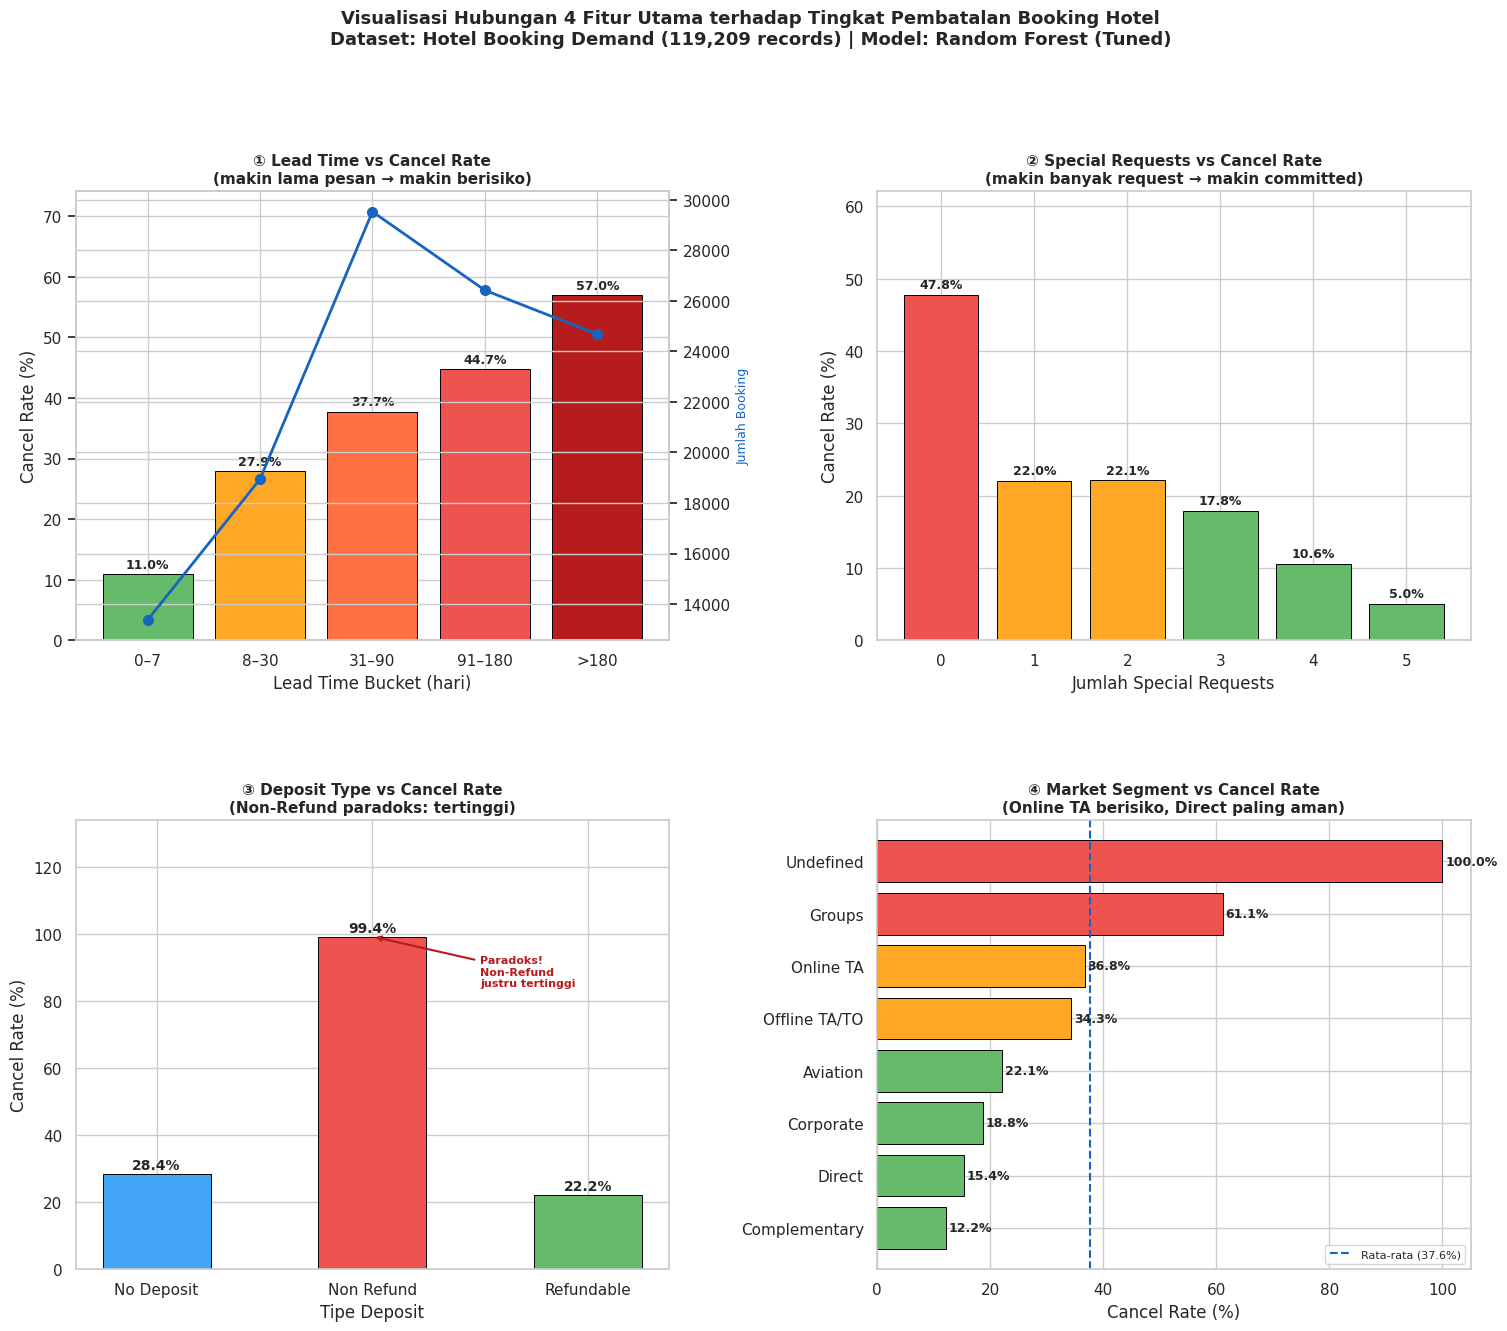

In [19]:
# VISUALISASI 4 FITUR UTAMA
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)
df_plot = df.copy()  # df dari hasil load dataset

# Lead time bucket
df_plot['lt_bucket'] = pd.cut(
    df_plot['lead_time'],
    bins=[0, 7, 30, 90, 180, 737],
    labels=['0–7', '8–30', '31–90', '91–180', '>180']
)

# CHART 1: Lead Time vs Cancel Rate
ax1 = fig.add_subplot(gs[0, 0])
lt_cancel = df_plot.groupby('lt_bucket', observed=True)['is_canceled'].mean() * 100
lt_count  = df_plot.groupby('lt_bucket', observed=True).size()

bars = ax1.bar(lt_cancel.index, lt_cancel.values,
               color=['#66BB6A','#FFA726','#FF7043','#EF5350','#B71C1C'],
               edgecolor='black', linewidth=0.7)
ax2_twin = ax1.twinx()
ax2_twin.plot(range(len(lt_count)), lt_count.values,
              color='#1565C0', marker='o', lw=2, ms=7, label='Volume')
ax2_twin.set_ylabel('Jumlah Booking', color='#1565C0', fontsize=9)

ax1.set_title('① Lead Time vs Cancel Rate\n(makin lama pesan → makin berisiko)',
              fontweight='bold', fontsize=11)
ax1.set_xlabel('Lead Time Bucket (hari)')
ax1.set_ylabel('Cancel Rate (%)')
ax1.set_ylim(0, lt_cancel.max() * 1.3)
for bar, val in zip(bars, lt_cancel.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

#CHART 2: Special Requests vs Cancel Rate
ax2 = fig.add_subplot(gs[0, 1])
sr_cancel = df_plot.groupby('total_of_special_requests')['is_canceled'].mean() * 100

colors_sr = ['#EF5350' if v == sr_cancel.max() else
             '#FFA726' if v > sr_cancel.mean() else '#66BB6A'
             for v in sr_cancel.values]
bars2 = ax2.bar(sr_cancel.index, sr_cancel.values,
                color=colors_sr, edgecolor='black', linewidth=0.7)
ax2.set_title('② Special Requests vs Cancel Rate\n(makin banyak request → makin committed)',
              fontweight='bold', fontsize=11)
ax2.set_xlabel('Jumlah Special Requests')
ax2.set_ylabel('Cancel Rate (%)')
ax2.set_ylim(0, sr_cancel.max() * 1.3)
ax2.set_xticks(sr_cancel.index)
for bar, val in zip(bars2, sr_cancel.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

# CHART 3: Deposit Type vs Cancel Rate
ax3 = fig.add_subplot(gs[1, 0])

# Map encoded ke label
dep_map = {0: 'No Deposit', 1: 'Non Refund', 2: 'Refundable'}
df_plot['deposit_label'] = df_plot['deposit_type_enc'].map(dep_map)
dep_cancel = df_plot.groupby('deposit_label')['is_canceled'].mean() * 100
dep_count  = df_plot.groupby('deposit_label').size()

dep_order  = ['No Deposit', 'Non Refund', 'Refundable']
dep_cancel = dep_cancel.reindex([d for d in dep_order if d in dep_cancel.index])
dep_colors = ['#42A5F5', '#EF5350', '#66BB6A'][:len(dep_cancel)]

bars3 = ax3.bar(dep_cancel.index, dep_cancel.values,
                color=dep_colors, edgecolor='black', linewidth=0.7, width=0.5)
ax3.set_title('③ Deposit Type vs Cancel Rate\n(Non-Refund paradoks: tertinggi)',
              fontweight='bold', fontsize=11)
ax3.set_xlabel('Tipe Deposit')
ax3.set_ylabel('Cancel Rate (%)')
ax3.set_ylim(0, dep_cancel.max() * 1.35)
for bar, val in zip(bars3, dep_cancel.values):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Tambahkan anotasi paradoks
nr_idx = list(dep_cancel.index).index('Non Refund') if 'Non Refund' in dep_cancel.index else -1
if nr_idx >= 0:
    ax3.annotate('Paradoks!\nNon-Refund\njustru tertinggi',
                 xy=(nr_idx, dep_cancel['Non Refund']),
                 xytext=(nr_idx + 0.5, dep_cancel['Non Refund'] * 0.85),
                 fontsize=8, color='#B71C1C', fontweight='bold',
                 arrowprops=dict(arrowstyle='->', color='#B71C1C', lw=1.5))

# ── CHART 4: Market Segment vs Cancel Rate ───────────────────
ax4 = fig.add_subplot(gs[1, 1])

mkt_map = {0:'Aviation', 1:'Complementary', 2:'Corporate',
           3:'Direct', 4:'Groups', 5:'Offline TA/TO',
           6:'Online TA', 7:'Undefined'}
df_plot['market_label'] = df_plot['market_segment_enc'].map(mkt_map)
mkt_cancel = df_plot.groupby('market_label')['is_canceled'].mean() * 100
mkt_cancel = mkt_cancel.sort_values(ascending=True)

# Warna: merah = tinggi, hijau = rendah
palette = []
for v in mkt_cancel.values:
    if v >= mkt_cancel.quantile(0.75):
        palette.append('#EF5350')
    elif v >= mkt_cancel.median():
        palette.append('#FFA726')
    else:
        palette.append('#66BB6A')

bars4 = ax4.barh(mkt_cancel.index, mkt_cancel.values,
                  color=palette, edgecolor='black', linewidth=0.7)
ax4.set_title('④ Market Segment vs Cancel Rate\n(Online TA berisiko, Direct paling aman)',
              fontweight='bold', fontsize=11)
ax4.set_xlabel('Cancel Rate (%)')
ax4.axvline(mkt_cancel.mean(), color='#1565C0', linestyle='--',
            lw=1.5, label=f'Rata-rata ({mkt_cancel.mean():.1f}%)')
ax4.legend(fontsize=8)
for bar, val in zip(bars4, mkt_cancel.values):
    ax4.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', fontsize=9, fontweight='bold')

# ── Judul besar ───────────────────────────────────────────────
fig.suptitle(
    'Visualisasi Hubungan 4 Fitur Utama terhadap Tingkat Pembatalan Booking Hotel\n'
    'Dataset: Hotel Booking Demand (119,209 records) | Model: Random Forest (Tuned)',
    fontweight='bold', fontsize=13, y=1.01
)

plt.savefig('fig_4_fitur_utama.png', dpi=180, bbox_inches='tight')
plt.show()